# 1.Import necessary Libraries

In [30]:
pip install scikit-learn

     ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/8.9 MB 991.0 kB/s eta 0:00:09
      --------------------------------------- 0.1/8.9 MB 1.3 MB/s eta 0:00:07
      --------------------------------------- 0.2/8.9 MB 1.3 MB/s eta 0:00:07
     - -------------------------------------- 0.3/8.9 MB 1.8 MB/s eta 0:00:05
     - -------------------------------------- 0.4/8.9 MB 1.6 MB/s eta 0:00:06
     -- ------------------------------------- 0.5/8.9 MB 1.8 MB/s eta 0:00:05
     -- ------------------------------------- 0.6/8.9 MB 1.9 MB/s eta 0:00:05
     --- ------------------------------------ 0.7/8.9 MB 2.0 MB/s eta 0:00:05
     --- ------------------------------------ 0.8/8.9 MB 2.1 MB/s eta 0:00:04
     ---- ----------------------------------- 0.9/8.9 MB 2.1 MB/s eta 0:00:04
     ---- ----------------------------------- 1.1/8.9 MB 2.2 MB/s eta 0:00:04
     ----- ---------------------------------- 1.2/8.9 MB 2.2 MB/s eta


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 2.Import DataSet

In [2]:
cars_Data = pd.read_csv("Cars.csv")
cars_Data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


# 3.Data Understanding

#### 3.1.1 Perform Initial investigation on the data

In [3]:
cars_Data.shape


(81, 5)

In [4]:
cars_Data.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [6]:
cars_Data.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [7]:
cars_Data.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


### Now let's Check the assumptions!

## Test 1:Linearity Test

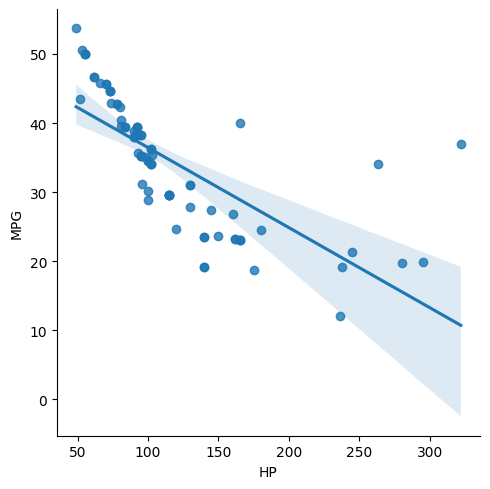

In [13]:
sns.lmplot(data=cars_Data, x="HP", y="MPG")

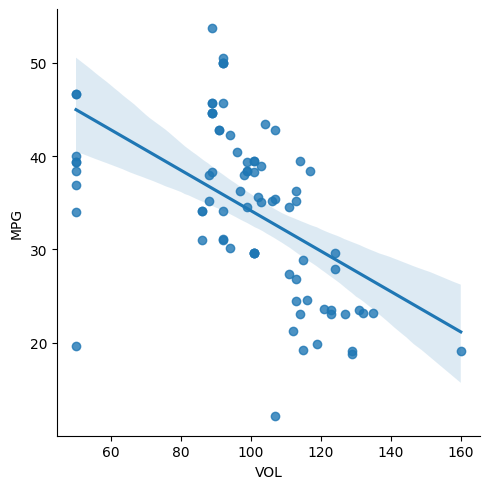

In [16]:
sns.lmplot(data=cars_Data, x="VOL", y="MPG")

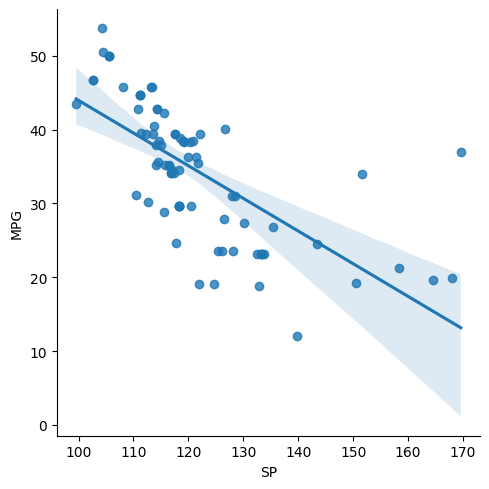

In [15]:
sns.lmplot(data=cars_Data, x="SP", y="MPG")


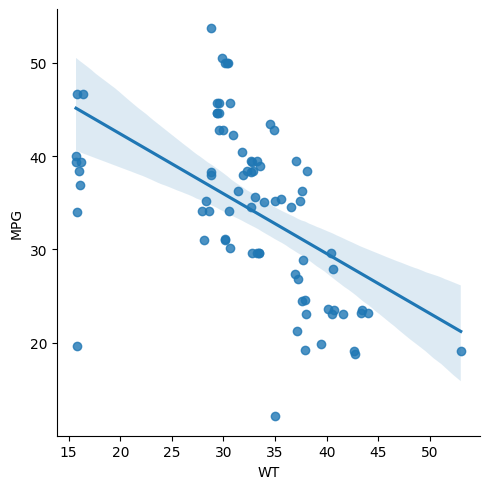

In [14]:
sns.lmplot(data=cars_Data, x="WT", y="MPG")


#### Test 1 Linearity Failed

## Test 2 Normality Test

#### Need to get bell shaped curve

(array([15., 35.,  9.,  6.,  9.,  0.,  2.,  2.,  1.,  2.]),
 array([ 49. ,  76.3, 103.6, 130.9, 158.2, 185.5, 212.8, 240.1, 267.4,
        294.7, 322. ]),
 <BarContainer object of 10 artists>)

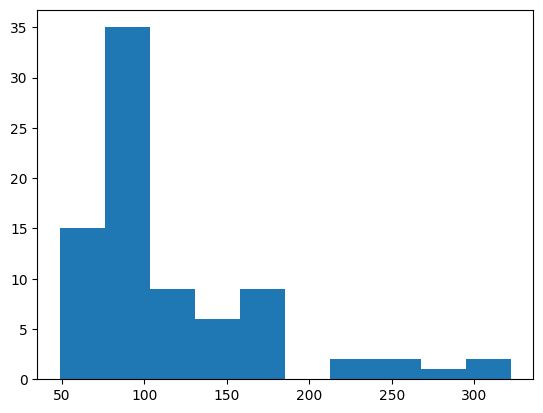

In [17]:
plt.hist(data=cars_Data,x="HP")

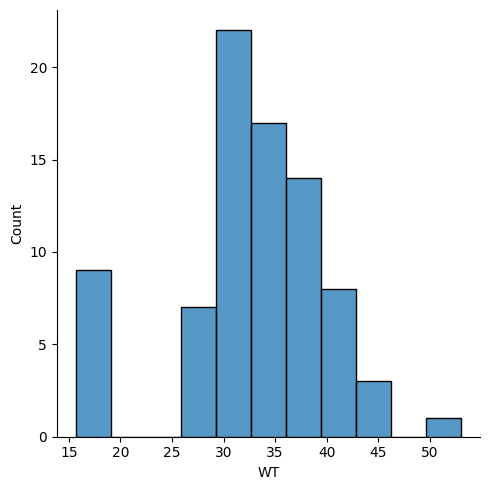

In [20]:
sns.displot(data=cars_Data,x="WT")

#### Test 2 Normality Failed

## Test 3 - Multicollinearity Test

In [23]:
corre_matrix = cars_Data.corr()
corre_matrix

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


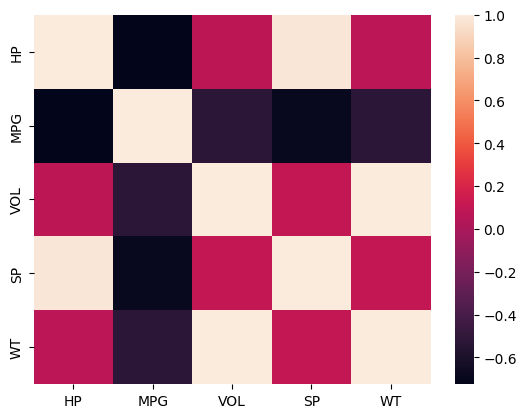

In [26]:
sns.heatmap(data=corre_matrix)
plt.show()

#### Test 3 fails Multicollinearity exists

#### Test 4 passed - Auto Regression

# 4.Data Preparation

In [33]:
cars_Data
X=cars_Data[["HP","VOL","SP","WT"]]
Y=cars_Data["MPG"]

#### There is no data preparation required as all data is numeric

# 5.Model Building

In [53]:
model = LinearRegression()

# 6.Model Training

In [54]:
model.fit(X,Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [55]:
model.intercept_

np.float64(30.67733585215165)

In [56]:
model.coef_

array([-0.20544372, -0.33605084,  0.39562692,  0.40057409])

# 7.Model Testing

In [57]:
Y_Pred = model.predict(X)
Y_Pred

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21

# 8.Model Evaluation

In [51]:
Error = Y-Y_Pred
Error

0     10.258747
1      7.624608
2      7.734060
3      3.157963
4      8.331584
        ...    
76    15.617904
77     1.298838
78     7.863547
79     7.517122
80    -3.458218
Name: MPG, Length: 81, dtype: float64

#### Let's Perform Homoscedasticity

#### Test 5 Homoscedasity Fails


#### Test 6 Zero residual mean - Actual output vs Predicted output should be linear